# Yelp — Анализ исходного датасета и выбор среза (EDA_1)
### Групповой проект №5 · Deep Learning · НИУ ВШЭ БИ

Это **первый** ноутбук конвейера. Полный датасет Yelp — это ~7 млн отзывов по десяткам
городов и несколько ГБ текста; обучать на нём все модели и хранить его целиком неудобно и
невоспроизводимо. Поэтому здесь мы:

1. смотрим на **сырые** данные (состав файлов, схемы, объёмы) — что вообще есть до обработки;
2. считаем по каждому городу метрики, важные для **обеих** задач проекта;
3. по прозрачным критериям выбираем **срез из 2–3 городов**, на котором дальше работает весь проект.

**Конвейер:** `EDA_1.ipynb` (выбор среза, этот файл) → `scripts/preprocess.py` (нарезка
выбранных городов в parquet) → `EDA_2.ipynb` (глубокий EDA готового среза под модели).

> Тяжёлые файлы (`review.json` 5.3 ГБ) читаем **потоково и с отбором колонок** (polars),
> поэтому 5 ГБ текста в память не загружается.

In [1]:
import sys, json, math, re
from pathlib import Path
from itertools import combinations
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(root))
from _constants import (
    RAW, BUSINESS, REVIEW, USER, TIP, FILES,
    REPORTS, ARTIFACTS, DEFAULT_CITIES, ENABLE_ARTIFACTS,
)
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
STARS = [1, 2, 3, 4, 5]
SEED = 42
REPORTS.mkdir(parents=True, exist_ok=True)
NB = "EDA_1"
def savefig(name):
    if not ENABLE_ARTIFACTS:
        return
    ARTIFACTS.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(ARTIFACTS / f"{NB}_{name}.png", bbox_inches="tight", dpi=140)
print("RAW:", RAW, "| ENABLE_ARTIFACTS:", ENABLE_ARTIFACTS)

RAW: /Users/popov-viktor/Downloads/yelp_project/data/raw | ENABLE_ARTIFACTS: False


## 1. Обзор сырых файлов

Из 5 файлов Yelp двум нашим задачам нужны 4: `business` (заведения), `review` (отзывы с
оценкой — таргет), `user` (профили), `tip` (короткие заметки **без** оценки — сырьё для
inference в Задаче 2). `checkin` не используем. Смотрим размеры и схемы (колонки), не загружая
текст: схему берём с первых строк, объёмы — потоково.

In [2]:
rows = []
for name in FILES:
    p = RAW / name
    size_mb = p.stat().st_size / 1e6 if p.exists() else 0
    schema = pl.scan_ndjson(p, infer_schema_length=500).collect_schema()
    short = name.replace("yelp_academic_dataset_", "").replace(".json", "")
    rows.append({"файл": short, "размер, МБ": round(size_mb), "колонок": len(schema),
                 "колонки": ", ".join(list(schema.names())[:8]) + (" …" if len(schema) > 8 else "")})
files_overview = pd.DataFrame(rows)
display(files_overview)
def n_rows(p):
    return pl.scan_ndjson(p, infer_schema_length=500).select(pl.len()).collect(engine="streaming").item()
counts = {"business": n_rows(BUSINESS), "review": n_rows(REVIEW),
          "user": n_rows(USER), "tip": n_rows(TIP)}
for k, v in counts.items():
    print(f"{k:9s}: {v:>10,} записей")

,файл,"размер, МБ",колонок,колонки
0,business,119,14,"business_id, name, address, city, state, posta..."
1,review,5342,9,"review_id, user_id, business_id, stars, useful..."
2,user,3363,22,"user_id, name, review_count, yelping_since, us..."
3,tip,181,5,"user_id, business_id, text, date, compliment_c..."


business :    150,346 записей
review   :  6,990,280 записей
user     :  1,987,897 записей
tip      :    908,915 записей


## 2. Вспомогательные функции

- `normalize_city_state` — приводит «город, штат» к каноническому виду и склеивает написания
  `Saint`/`St.` (иначе один город дробится на «Saint Louis» и «St. Louis»);
- `norm_entropy` — нормированная (на `log 5`) энтропия распределения оценок: 1.0 — идеально
  ровно по 1–5★, ближе к 0 — всё в один класс. Это мера **сбалансированности** для Задачи 2.

In [3]:
def normalize_city_state(city, state):
    c = (city.fillna("").astype(str).str.strip().str.lower()
         .str.replace(".", "", regex=False)
         .str.replace(r"^saint\s+", "st ", regex=True)
         .str.replace(r"\s+", " ", regex=True).str.strip().str.title())
    return c + ", " + state.fillna("").astype(str)
def norm_entropy(counts):
    counts = np.asarray(counts, dtype=float)
    tot = counts.sum()
    if tot == 0:
        return 0.0
    p = counts[counts > 0] / tot
    return float(-(p * np.log(p)).sum() / math.log(5))

## 3. Метрики по городам

Для выбора среза по каждому городу считаем: **объём** отзывов, **баланс оценок** (norm_entropy),
долю негатива (1–2★) и число **типсов**. Карту `business → город` берём из `business.json`, а
оценки — потоково из `review.json` (только колонки `business_id` и `stars`, текст не трогаем).

In [4]:
biz = pd.read_json(BUSINESS, lines=True)
biz["city_state"] = normalize_city_state(biz["city"], biz["state"])
bid2city = dict(zip(biz["business_id"], biz["city_state"]))
rev = (pl.scan_ndjson(REVIEW, infer_schema_length=1000)
         .select(["business_id", "stars"]).collect(engine="streaming"))
rev = rev.with_columns(
    pl.col("business_id").replace_strict(bid2city, default=None).alias("city_state"))
star_ct = (rev.drop_nulls("city_state").group_by(["city_state", "stars"]).len()
           .to_pandas().pivot(index="city_state", columns="stars", values="len").fillna(0))
for s in STARS:
    if s not in star_ct.columns:
        star_ct[s] = 0
star_ct = star_ct[STARS]
city_tot = star_ct.sum(axis=1).sort_values(ascending=False)
tip = pd.read_json(TIP, lines=True)[["business_id"]]
tip["city_state"] = tip["business_id"].map(bid2city)
tips_by_city = tip.dropna(subset=["city_state"]).groupby("city_state").size()
per_city = {}
for cs in city_tot.index:
    counts = star_ct.loc[cs, STARS].to_numpy()
    tot = int(counts.sum())
    per_city[cs] = {
        "total_reviews": tot,
        "star_counts": {int(s): int(counts[i]) for i, s in enumerate(STARS)},
        "tips": int(tips_by_city.get(cs, 0)),
        "norm_entropy": norm_entropy(counts),
        "neg_share_1_2": float((counts[0] + counts[1]) / tot),
    }
json.dump({"per_city_reviews": per_city},
          open(REPORTS / "eda_stats.json", "w"), indent=2)
tbl = (pd.DataFrame(per_city).T
       .assign(total_reviews=lambda d: d["total_reviews"].astype(int),
               tips=lambda d: d["tips"].astype(int))
       .sort_values("total_reviews", ascending=False)
       [["total_reviews", "norm_entropy", "neg_share_1_2", "tips"]])
display(tbl.head(16).style.format({"total_reviews": "{:,.0f}", "tips": "{:,.0f}",
                                   "norm_entropy": "{:.3f}", "neg_share_1_2": "{:.1%}"}))

,total_reviews,norm_entropy,neg_share_1_2,tips
"Philadelphia, PA","967,871",0.882,20.2%,"118,557"
"New Orleans, LA","635,521",0.835,16.9%,"84,860"
"Tampa, FL","455,463",0.858,23.4%,"63,491"
"Nashville, TN","451,727",0.859,21.0%,"52,545"
"Tucson, AZ","405,287",0.864,25.3%,"57,532"
"Indianapolis, IN","361,584",0.859,20.2%,"55,330"
"Reno, NV","351,737",0.844,24.5%,"42,717"
"St Louis, MO","342,437",0.866,20.7%,"53,739"
"Santa Barbara, CA","269,887",0.785,17.9%,"28,461"
"St Petersburg, FL","157,570",0.830,21.1%,"20,086"


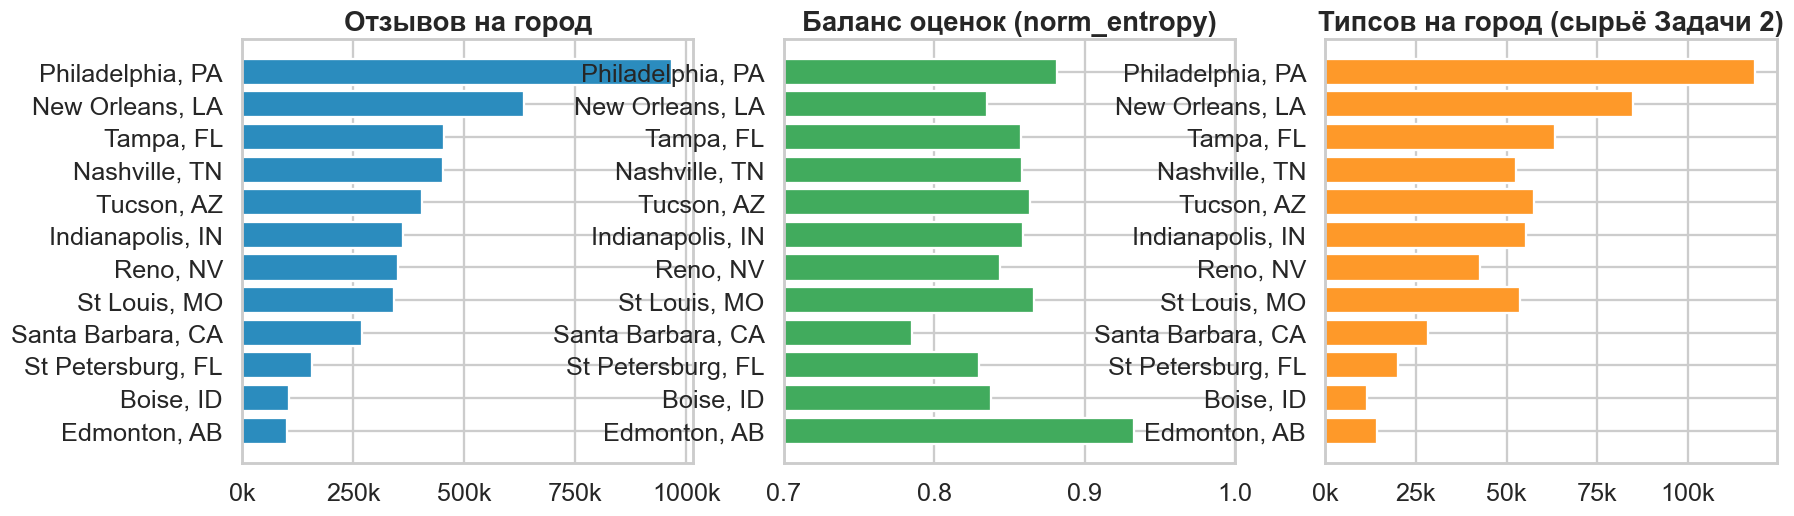

In [5]:
top = tbl.head(12)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].barh(top.index[::-1], top["total_reviews"][::-1], color="#2b8cbe")
axes[0].set_title("Отзывов на город")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
axes[1].barh(top.index[::-1], top["norm_entropy"][::-1], color="#41ab5d")
axes[1].set_title("Баланс оценок (norm_entropy)")
axes[1].set_xlim(0.7, 1.0)
axes[2].barh(top.index[::-1], top["tips"][::-1], color="#fe9929")
axes[2].set_title("Типсов на город (сырьё Задачи 2)")
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
savefig("cities_overview")
plt.show()

## 4. Дополнительные проверки сырых данных (до нарезки среза)

Прежде чем фиксировать срез, полезно убедиться в общих свойствах данных, от которых зависит
корректность обеих задач: глобальное распределение оценок, насколько внимание сконцентрировано
в немногих городах, какого рода заведения преобладают и на каком языке отзывы.

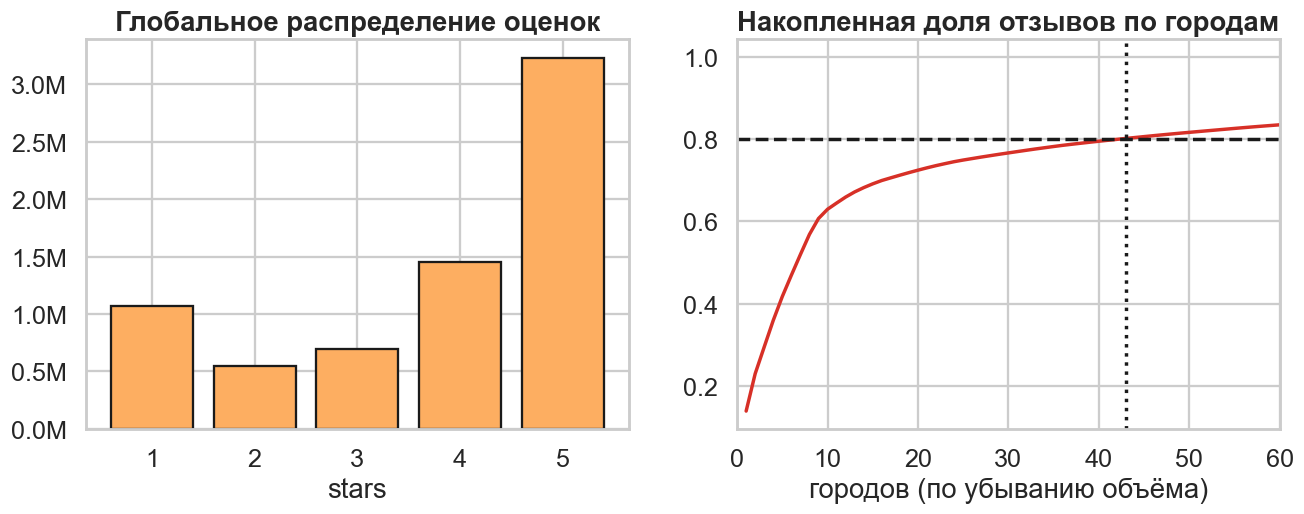

Всего городов (city_state): 1,254
80% всех отзывов дают всего 43 городов → данные сильно сконцентрированы,
  поэтому срез из нескольких крупных городов покрывает основную массу сигнала.
Глобальная средняя оценка: 3.75 ★


In [6]:
g_stars = rev.group_by("stars").len().sort("stars").to_pandas()
share_sorted = city_tot / city_tot.sum()
cum = share_sorted.cumsum().reset_index(drop=True)
n_cities_80 = int((cum < 0.8).sum()) + 1
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
axes[0].bar(g_stars["stars"], g_stars["len"], color="#fdae61", edgecolor="k")
axes[0].set_title("Глобальное распределение оценок")
axes[0].set_xlabel("stars")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
axes[1].plot(range(1, len(cum) + 1), cum.values, color="#d73027")
axes[1].axhline(0.8, ls="--", color="k")
axes[1].axvline(n_cities_80, ls=":", color="k")
axes[1].set_title("Накопленная доля отзывов по городам")
axes[1].set_xlabel("городов (по убыванию объёма)")
axes[1].set_xlim(0, 60)
savefig("stars_concentration")
plt.show()
print(f"Всего городов (city_state): {city_tot.shape[0]:,}")
print(f"80% всех отзывов дают всего {n_cities_80} городов → данные сильно сконцентрированы,")
print("  поэтому срез из нескольких крупных городов покрывает основную массу сигнала.")
print(f"Глобальная средняя оценка: {(g_stars['stars']*g_stars['len']).sum()/g_stars['len'].sum():.2f} ★")

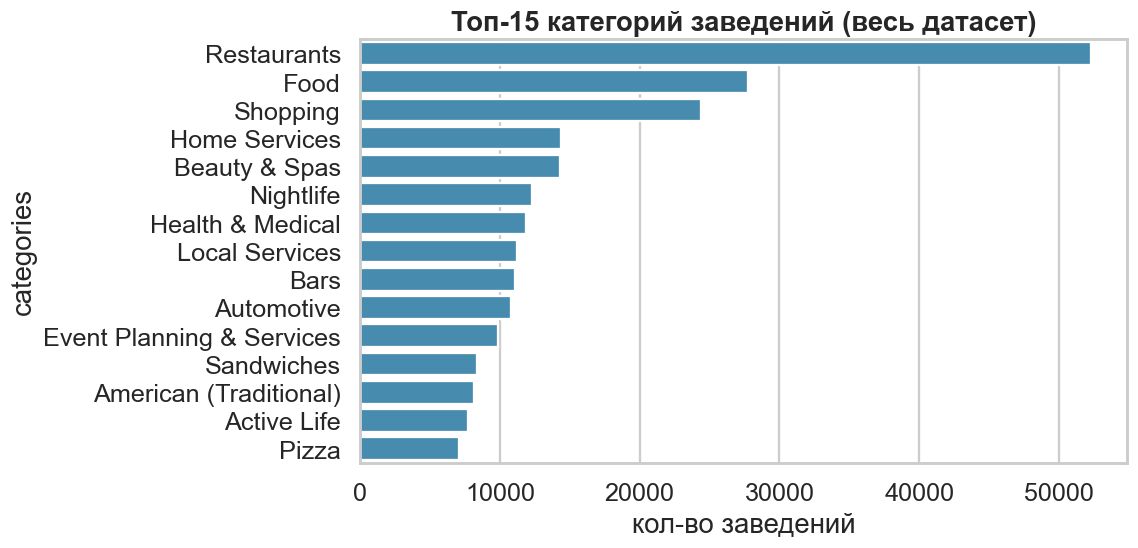

Заведений с указанным ценовым диапазоном: 57%
Открытых заведений (is_open=1): 80%
Категории показывают: датасет — про еду/услуги, что согласуется с обеими задачами.


In [7]:
cats = biz["categories"].dropna().str.split(", ").explode()
top_cats = cats.value_counts().head(15)
def get_price(a):
    if isinstance(a, dict):
        v = a.get("RestaurantsPriceRange2")
        try:
            return int(v)
        except (TypeError, ValueError):
            return None
    return None
has_price = biz["attributes"].apply(get_price).notna().mean() if "attributes" in biz else 0
open_share = biz["is_open"].mean() if "is_open" in biz else float("nan")
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=top_cats.values, y=top_cats.index, ax=ax, color="#3690c0")
ax.set_title("Топ-15 категорий заведений (весь датасет)")
ax.set_xlabel("кол-во заведений")
savefig("categories")
plt.show()
print(f"Заведений с указанным ценовым диапазоном: {has_price:.0%}")
print(f"Открытых заведений (is_open=1): {open_share:.0%}")
print("Категории показывают: датасет — про еду/услуги, что согласуется с обеими задачами.")

In [8]:
import langid
sample_txt = (pl.scan_ndjson(REVIEW, infer_schema_length=1000)
                .select("text").head(4000).collect())["text"].to_list()
langs = pd.Series([langid.classify(str(t)[:400])[0] for t in sample_txt])
print("Доли языков (сэмпл 4k отзывов):")
print((langs.value_counts(normalize=True).head(5) * 100).round(2).astype(str) + " %")
print(f"\nДоля английского: {(langs=='en').mean():.0%} → Задачу 2 строим на английском, "
      "редкие не-англ. отзывы фильтруем на препроцессинге NLP.")

Доли языков (сэмпл 4k отзывов):
en    99.9 %
es    0.02 %
ja    0.02 %
da    0.02 %
nl    0.02 %
Name: proportion, dtype: object

Доля английского: 100% → Задачу 2 строим на английском, редкие не-англ. отзывы фильтруем на препроцессинге NLP.


## 5. Выбор городов-среза

Критерии (закрывают потребности обеих задач):

- **2–3 крупных города**, в каждом ≥ 100k отзывов и ≥ 5k типсов;
- суммарный объём **400k – 700k** отзывов (хватает на обучение, но влезает в память) с целью ~600k;
- объединённый **баланс оценок** (norm_entropy) ≥ 0.87 — чтобы у Задачи 2 были все классы;
- при прочих равных — **максимум типсов** (бесплатное сырьё без оценки для Задачи 2).

Перебираем все сочетания, отбираем подходящие, сортируем по числу типсов и близости к ~600k.

In [9]:
MIN_TOTAL, MAX_TOTAL, TARGET = 400_000, 700_000, 600_000
ENTROPY_FLOOR, MIN_TIPS_TOTAL = 0.87, 10_000
MIN_CITY_REVIEWS, MIN_CITY_TIPS = 100_000, 5_000
cand = {cs: d for cs, d in per_city.items()
        if d["total_reviews"] >= MIN_CITY_REVIEWS and d["tips"] >= MIN_CITY_TIPS}
results = []
for k in (2, 3):
    for combo in combinations(cand, k):
        pooled = np.zeros(5)
        total = tips = 0
        for cs in combo:
            pooled += np.array([cand[cs]["star_counts"][s] for s in STARS])
            total += cand[cs]["total_reviews"]
            tips += cand[cs]["tips"]
        ent = norm_entropy(pooled)
        if MIN_TOTAL <= total <= MAX_TOTAL and tips >= MIN_TIPS_TOTAL and ent >= ENTROPY_FLOOR:
            results.append({"cities": list(combo), "total_reviews": total, "tips_total": tips,
                            "pooled_norm_entropy": round(ent, 4),
                            "pooled_neg_share_1_2": round((pooled[0] + pooled[1]) / total, 4)})
results.sort(key=lambda r: (-r["tips_total"], abs(r["total_reviews"] - TARGET)))
best = results[0]
json.dump(best, open(REPORTS / "selected_cities.json", "w"), indent=2)
print("Лучшие наборы (по типсам, затем близости к 600k):")
for r in results[:6]:
    names = " + ".join(c.split(",")[0] for c in r["cities"])
    print(f"  {names:42s} {r['total_reviews']:>8,} отзывов  {r['tips_total']:>7,} типсов  "
          f"ent={r['pooled_norm_entropy']}")
print("\nВЫБРАН СРЕЗ:", best["cities"])
print(f"  {best['total_reviews']:,} отзывов, {best['tips_total']:,} типсов, "
      f"баланс={best['pooled_norm_entropy']}, негатив={best['pooled_neg_share_1_2']:.1%}")
print("\nDEFAULT_CITIES в _constants.py:", DEFAULT_CITIES)
print("Совпадает с выбором:", sorted(best["cities"]) == sorted(DEFAULT_CITIES))

Лучшие наборы (по типсам, затем близости к 600k):
  Tucson + St Petersburg + Edmonton           664,751 отзывов   91,803 типсов  ent=0.8722
  Tampa + Boise + Edmonton                    662,783 отзывов   89,112 типсов  ent=0.8711
  St Louis + St Petersburg + Edmonton         601,901 отзывов   88,010 типсов  ent=0.873
  Tucson + Boise + Edmonton                   612,607 отзывов   83,153 типсов  ent=0.8767
  Indianapolis + Boise + Edmonton             568,904 отзывов   80,951 типсов  ent=0.8737
  St Louis + Boise + Edmonton                 549,757 отзывов   79,360 типсов  ent=0.8786

ВЫБРАН СРЕЗ: ['Tucson, AZ', 'St Petersburg, FL', 'Edmonton, AB']
  664,751 отзывов, 91,803 типсов, баланс=0.8722, негатив=24.1%

DEFAULT_CITIES в _constants.py: ['Tucson, AZ', 'St Petersburg, FL', 'Edmonton, AB']
Совпадает с выбором: True


## 6. Итог

Алгоритм выбрал срез, зафиксированный в `_constants.DEFAULT_CITIES`:

- **Tucson, AZ + St Petersburg, FL + Edmonton, AB** — ~665k отзывов и ~92k типсов;
- классы оценок сбалансированы (есть негатив для Задачи 2), города географически разные
  (юг США + Канада) — модель не переобучится под один рынок.

Этот набор по умолчанию режется скриптом `scripts/preprocess.py` в `data/processed/*.parquet`
(потоково, без загрузки сырья в память), а его глубокий разведочный анализ под конкретные
архитектуры — в `EDA_2.ipynb`. Отчёты сохранены в `reports/eda_stats.json` и
`reports/selected_cities.json`.